In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\shada\Downloads\titanic.csv\titanic.csv")

In [3]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df["Age"] = df["Age"].fillna(df["Age"]).median()

In [7]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [8]:
df.drop("Cabin" ,axis =1 , inplace = True) #droping cabins

In [9]:
df.isnull().sum() #verifying

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [10]:
df.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,28.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,28.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,28.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,28.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,28.0,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,28.0,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,28.0,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,28.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,28.0,1,0,237736,30.0708,C


In [11]:
df["Sex"] = df["Sex"].map({"male" : 0 , "female" : 1 })

In [12]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

In [13]:
df["Survived"].mean()

np.float64(0.3838383838383838)

In [14]:
df.groupby("Sex")["Survived"].mean()

Sex
0    0.188908
1    0.742038
Name: Survived, dtype: float64

In [15]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [16]:
df.drop(["Name", "Ticket"], axis=1, inplace=True)

In [17]:
df.corr()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
PassengerId,1.000000,-0.005007,-0.035144,-0.042939,NaN,-0.057527,-0.001652,0.012658,-0.033606,0.022204
Survived,-0.005007,1.000000,-0.338481,0.543351,NaN,-0.035322,0.081629,0.257307,0.003650,-0.149683
Pclass,-0.035144,-0.338481,1.000000,-0.131900,NaN,0.083081,0.018443,-0.549500,0.221009,0.074053
Sex,-0.042939,0.543351,-0.131900,1.000000,NaN,0.114631,0.245489,0.182333,0.074115,-0.119224
Age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SibSp,-0.057527,-0.035322,0.083081,0.114631,NaN,1.000000,0.414838,0.159651,-0.026354,0.068734
Parch,-0.001652,0.081629,0.018443,0.245489,NaN,0.414838,1.000000,0.216225,-0.081228,0.060814
Fare,0.012658,0.257307,-0.549500,0.182333,NaN,0.159651,0.216225,1.000000,-0.117216,-0.162184
Embarked_Q,-0.033606,0.003650,0.221009,0.074115,NaN,-0.026354,-0.081228,-0.117216,1.000000,-0.499421
Embarked_S,0.022204,-0.149683,0.074053,-0.119224,NaN,0.068734,0.060814,-0.162184,-0.499421,1.000000


In [18]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import sys
print(sys.executable)


C:\Python312\python.exe


In [20]:
import sys
!{sys.executable} -m pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
df.drop("PassengerId", axis=1, inplace=True)

In [23]:
df.drop("Age", axis=1, inplace=True)

In [24]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

df

,Survived,Pclass,Sex,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,1,0,7.2500,False,True
1,1,1,1,1,0,71.2833,False,False
2,1,3,1,0,0,7.9250,False,True
3,1,1,1,1,0,53.1000,False,True
4,0,3,0,0,0,8.0500,False,True
5,0,3,0,0,0,8.4583,True,False
6,0,1,0,0,0,51.8625,False,True
7,0,3,0,3,1,21.0750,False,True
8,1,3,1,0,2,11.1333,False,True
9,1,2,1,1,0,30.0708,False,False


In [25]:
df.head()
df.shape


(891, 8)

In [26]:
from sklearn.model_selection import train_test_split # divide data for train and test

X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [28]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy_score(y_test, y_pred)

0.7653631284916201

In [29]:
import pandas as pd
pd.DataFrame({"Feature": X.columns,
 "Coefficient": model.coef_[0]
})

,Feature,Coefficient
0,Pclass,-0.758159
1,Sex,2.607689
2,SibSp,-0.230609
3,Parch,-0.077451
4,Fare,0.002739
5,Embarked_Q,-0.210516
6,Embarked_S,-0.476066


In [30]:
from sklearn.metrics import confusion_matrix
confusion_matrix (y_test,y_pred)

array([[86, 19],
       [23, 51]])

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       105
           1       0.73      0.69      0.71        74

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.76      0.77      0.76       179



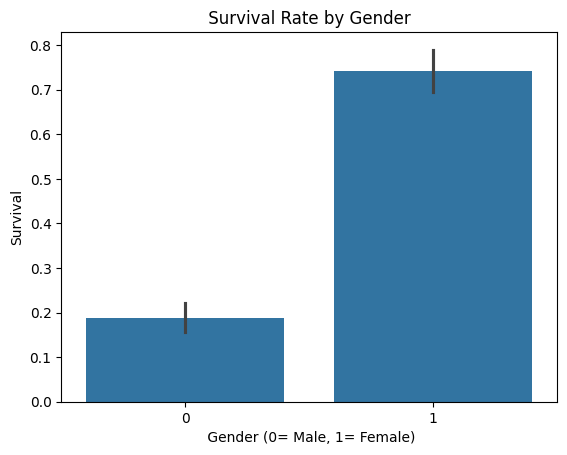

In [32]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.barplot(x="Sex" , y="Survived", data = df)

plt.title(" Survival Rate by Gender ")
plt.xlabel(" Gender (0= Male, 1= Female)")
plt.ylabel("Survival")
plt.show()

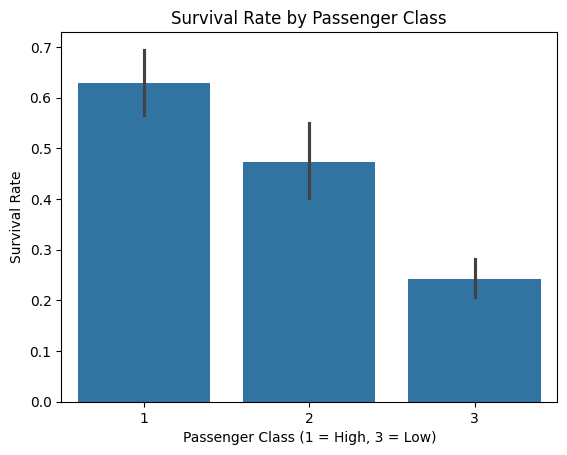

In [33]:
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class (1 = High, 3 = Low)")
plt.ylabel("Survival Rate")
plt.show()

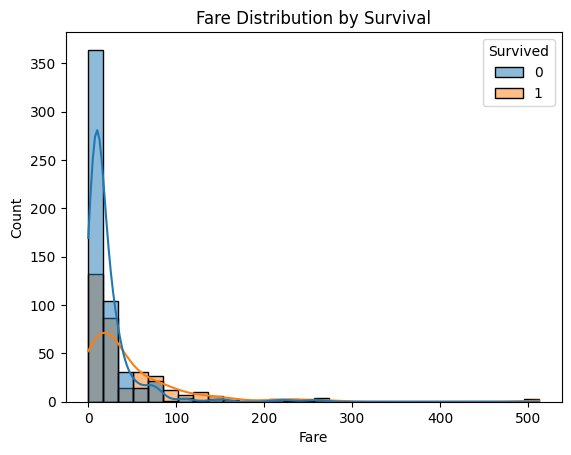

In [34]:
sns.histplot(data=df, x="Fare", hue="Survived", bins=30, kde=True) # smooth curved

plt.title("Fare Distribution by Survival")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

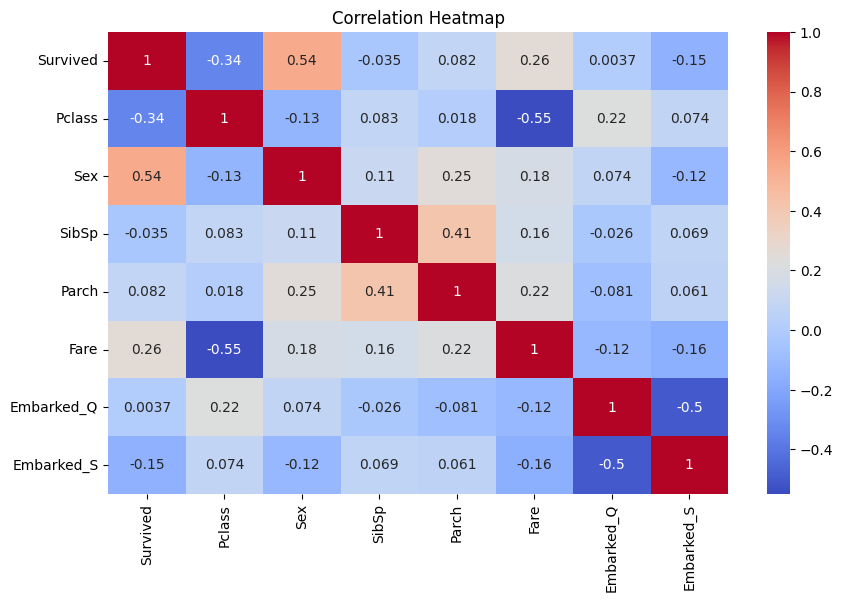

In [35]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [36]:
df.to_csv("titanic_cleaned.csv", index=False)

In [40]:
#hypothesis testing 
#chi2 func test are two variables independent or related
import pandas as pd
from scipy.stats import chi2_contingency
# crosstab will built the frequency table
table = pd.crosstab(df["Sex"], df["Survived"])
# this return the 4 values 
#dof is the degree of freedom 
chi2,p ,dof,expected = chi2_contingency(table)
print("p-value",p)

p-value 1.1973570627755645e-58


In [42]:
# T-Test
from scipy.stats import ttest_ind
survived = df[df["Survived"]==1]["Fare"]
not_survived = df[df["Survived"]==0]["Fare"]

t_stat,p_value = ttest_ind(survived , not_survived)

print("p_value:" , p_value)

p_value: 6.1201893419242075e-15


In [44]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
# SibSp is siblingsspouce , Parch is parentschildren  

In [45]:
df.groupby("FamilySize")["Survived"].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [48]:
df.groupby(["Sex" , "Pclass"]).mean().unstack() 
# in the output female + highclass = highest survival 

Survived                         SibSp                         Parch  \
Pclass         1         2         3         1         2         3         1   
Sex                                                                            
0       0.368852  0.157407  0.135447  0.311475  0.342593  0.498559  0.278689   
1       0.968085  0.921053  0.500000  0.553191  0.486842  0.895833  0.457447   

                                  Fare                       Embarked_Q  \
Pclass         2         3           1          2          3          1   
Sex                                                                       
0       0.222222  0.224784   67.226127  19.741782  12.661633   0.008197   
1       0.605263  0.798611  106.125798  21.970121  16.118810   0.010638   

                           Embarked_S                     FamilySize  \
Pclass         2         3          1         2         3          1   
Sex                                                                    
0       0.009259  0.112392   0.647541  0.898148  0.763689   1.590164   
1       0.026316  0.229167   0.531915  0.881579  0.611111   2.010638   

                            
Pclass         2         3  
Sex                         
0       1.564815  1.723343  
1       2.092105  2.694444

In [53]:
# checking skewness 
print(df["Fare"].skew())
#skewness is very high 4.78 means most passneger paid low fares but some paid very high fares

4.787316519674893


In [54]:
import numpy as np
df["Fare_log"] = np.log1p(df["Fare"])

In [55]:
df[["Fare" , "Fare_log"]].head()

,Fare,Fare_log
0,7.2500,2.110213
1,71.2833,4.280593
2,7.9250,2.188856
3,53.1000,3.990834
4,8.0500,2.202765


In [56]:
# the log transformation decreases the gap between small and large values

<function matplotlib.pyplot.show(close=None, block=None)>

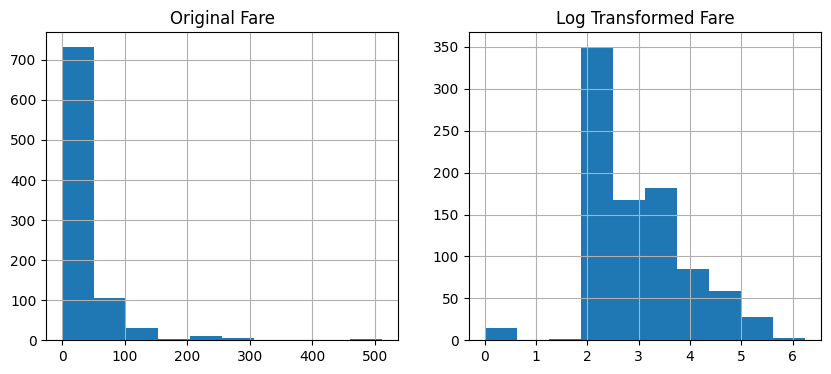

In [57]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
df["Fare"].hist()
plt.title("Original Fare")

plt.subplot(1,2,2)
df["Fare_log"].hist()
plt.title("Log Transformed Fare")

plt.show

In [58]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df["Fare"] < Q1 - 1.5*IQR) | (df["Fare"] > Q3+ 1.5*IQR)]
outliers.shape

(116, 10)